Nesse notebook são plotados os boxplots de algumas variáveis agregadas de acordo com os perfis.

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
update_prof = {'Episódico/Epidêmico':'Episodic/Epidemic', 'Epidêmico':'Epidemic', 'Episódico':'Episodic',
       'Transmissão Persistente':'Persistent Transmission', 'Sem transmissão': 'No Transmission', 
              'Sem transmissao': 'No Transmission'}

In [3]:
df_10_19 = pd.read_csv('../Determinantes/clima/clima_agg_10_19.csv', index_col = 'Unnamed: 0')

df_10_19.loc[:, 'dengue_pattern'] = df_10_19.dengue_pattern.replace(update_prof)

df_10_19['classi'] = '10_19'

df_10_19.head()

,geocodigo,temp_med,umid_med,precip_tot,thr_temp,thr_umid,thr_prec,thr_temp_umid,year,muni_code,dengue_pattern,classi
0,2700102,25.917411,71.160050,174.737289,364,314,2,314,2010,2700102,Episodic/Epidemic,10_19
1,2700201,25.484200,80.407899,424.205669,364,364,5,364,2010,2700201,Episodic/Epidemic,10_19
2,2700300,25.588142,77.216115,277.945870,364,364,2,364,2010,2700300,Epidemic,10_19
3,2700409,24.897218,81.989589,423.138619,364,364,4,364,2010,2700409,Episodic/Epidemic,10_19
4,2700508,25.800147,78.780638,491.421552,364,363,5,363,2010,2700508,Episodic,10_19


In [4]:
df_10_19.dengue_pattern.unique()

array(['Episodic/Epidemic', 'Epidemic', 'Episodic',
       'Persistent Transmission', 'No Transmission'], dtype=object)

Porcentagem de valores relacionados com cada perfil:

In [5]:
df_10_19.dengue_pattern.value_counts()/df_10_19.shape[0]

dengue_pattern
Episodic/Epidemic          0.537522
Episodic                   0.319569
Epidemic                   0.103052
No Transmission            0.037343
Persistent Transmission    0.002513
Name: count, dtype: float64

In [6]:
df_20_22 = pd.read_csv('../Determinantes/clima/clima_agg_20_22.csv', index_col = 'Unnamed: 0')

df_20_22.loc[:, 'dengue_pattern'] = df_20_22.dengue_pattern.replace(update_prof)

df_20_22['classi'] = '20_22'

df_20_22.dengue_pattern.value_counts()/df_20_22.shape[0]

dengue_pattern
Episodic/Epidemic          0.484919
Episodic                   0.300718
Epidemic                   0.163555
No Transmission            0.043806
Persistent Transmission    0.007002
Name: count, dtype: float64

In [7]:
df = pd.concat([df_10_19, df_20_22])

df.head()

,geocodigo,temp_med,umid_med,precip_tot,thr_temp,thr_umid,thr_prec,thr_temp_umid,year,muni_code,dengue_pattern,classi
0,2700102,25.917411,71.160050,174.737289,364,314,2,314,2010,2700102,Episodic/Epidemic,10_19
1,2700201,25.484200,80.407899,424.205669,364,364,5,364,2010,2700201,Episodic/Epidemic,10_19
2,2700300,25.588142,77.216115,277.945870,364,364,2,364,2010,2700300,Epidemic,10_19
3,2700409,24.897218,81.989589,423.138619,364,364,4,364,2010,2700409,Episodic/Epidemic,10_19
4,2700508,25.800147,78.780638,491.421552,364,363,5,363,2010,2700508,Episodic,10_19


In [8]:
df.loc[df.thr_prec > 0].thr_prec.max()

33

In [9]:
prof_order = ['No Transmission', 'Episodic', 'Episodic/Epidemic', 'Epidemic', 
       'Persistent Transmission']


Variáveis climáticas:

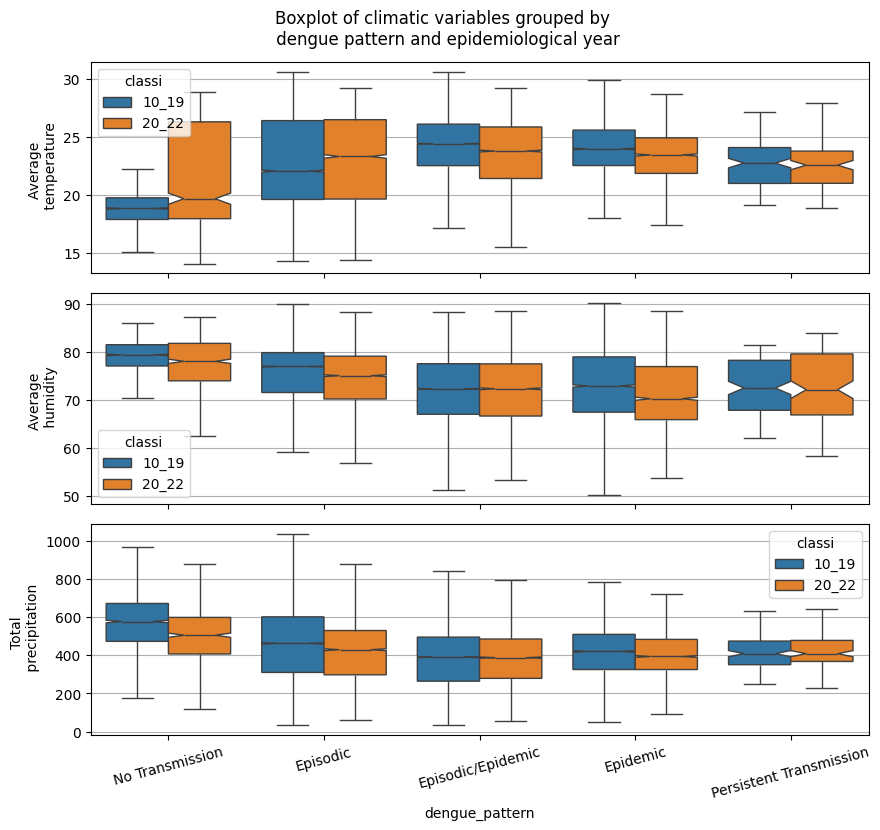

In [10]:
fig, ax = plt.subplots(3,1, figsize = (9, 8),  sharex = True)

sns.boxplot(x='dengue_pattern', y='temp_med', data=df, showfliers = False, order = prof_order, hue = 'classi', ax=ax[0],
           notch = True)

ax[0].set_ylabel('Average \n temperature')

ax[0].grid(True, axis='y')

sns.boxplot(x='dengue_pattern', y='umid_med', data=df, showfliers = False,order = prof_order,  hue = 'classi',ax=ax[1],notch = True)

ax[1].set_ylabel('Average \n humidity')

ax[1].grid(True, axis='y')


sns.boxplot(x='dengue_pattern', y='precip_tot', data=df, showfliers = False,order = prof_order, hue = 'classi', ax=ax[2],notch = True)

ax[2].set_ylabel('Total \n precipitation')

ax[2].grid(True, axis='y')


plt.suptitle('Boxplot of climatic variables grouped by \n dengue pattern and epidemiological year')

plt.tight_layout()
plt.xticks(rotation=15)  # Rotate x labels if needed

plt.savefig('../figures/boxplot_clima.png',  dpi = 300, bbox_inches = 'tight')
plt.show()

Variáveis de acordo com o somatório do dia:

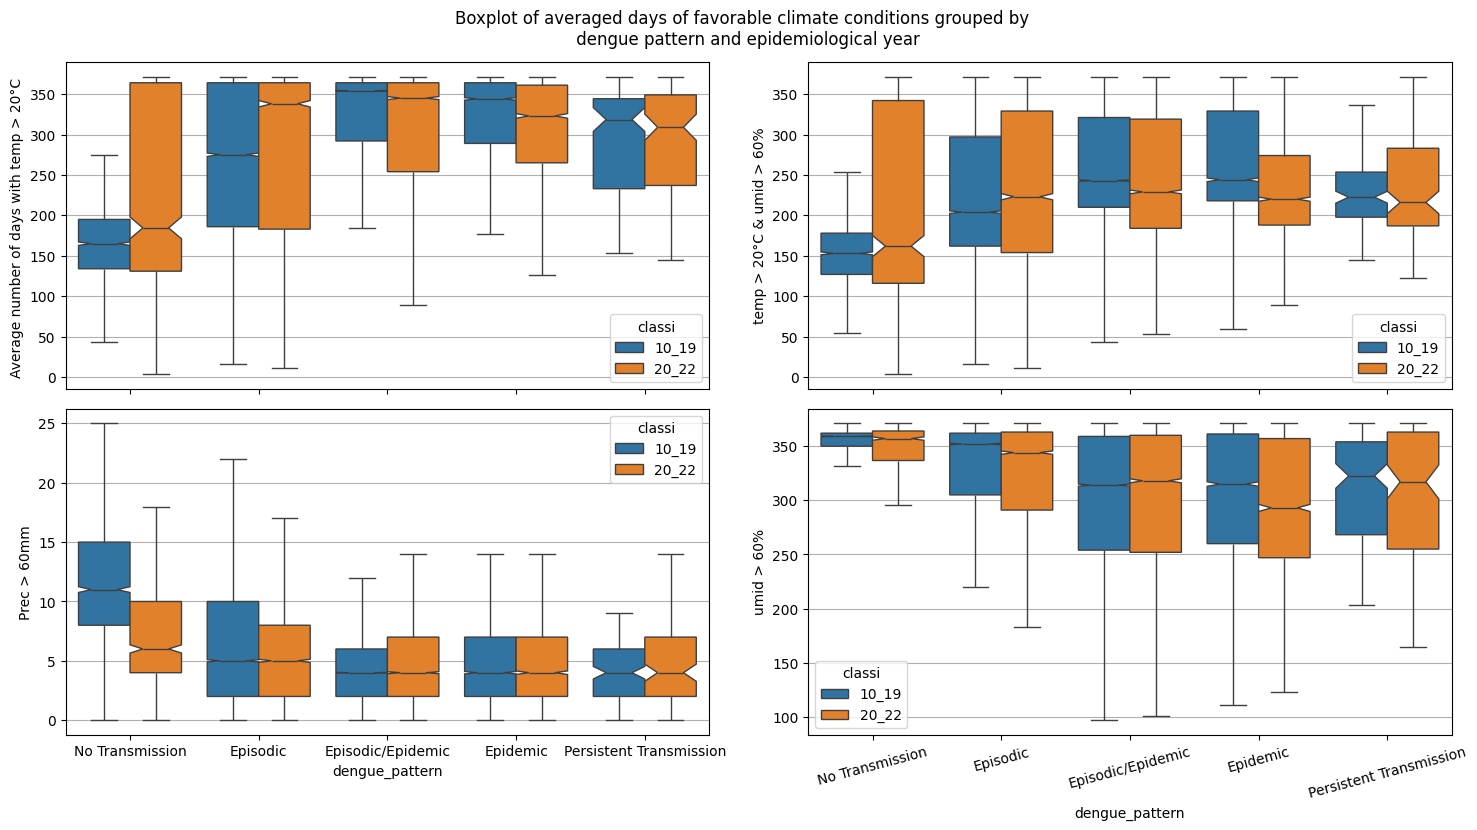

In [12]:
fig, ax = plt.subplots(2,2, figsize = (15, 8),  sharex = True)

sns.boxplot(x='dengue_pattern', y='thr_temp', data=df, showfliers = False, order = prof_order, hue = 'classi', ax=ax[0,0],
           notch = True)

ax[0,0].set_ylabel('Average number of days with temp > 20°C ')


sns.boxplot(x='dengue_pattern', y='thr_temp_umid', data=df, showfliers = False,order = prof_order,  hue = 'classi',ax=ax[0, 1],notch = True)

ax[0, 1].set_ylabel('temp > 20°C & umid > 60%')


sns.boxplot(x='dengue_pattern', y='thr_prec', data=df, showfliers = False,order = prof_order, hue = 'classi', ax=ax[1,0],notch = True)

ax[1,0].set_ylabel('Prec > 60mm')

sns.boxplot(x='dengue_pattern', y='thr_umid', data=df, showfliers = False,order = prof_order, hue = 'classi', ax=ax[1,1],notch = True)

ax[1,1].set_ylabel('umid > 60%')

for ax_ in ax.ravel():
    ax_.grid(True, axis='y')

plt.suptitle('Boxplot of averaged days of favorable climate conditions grouped by \n dengue pattern and epidemiological year')

plt.tight_layout()
plt.xticks(rotation=15)  # Rotate x labels if needed

#plt.savefig('../figures/boxplot_clima.png',  dpi = 300, bbox_inches = 'tight')
plt.show()

<Axes: xlabel='dengue_pattern', ylabel='temp_med'>

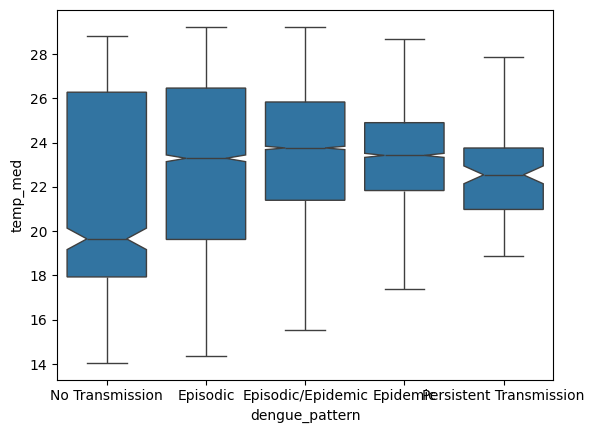

In [10]:
sns.boxplot(x='dengue_pattern', y='temp_med', data=df_20_22, showfliers = False, order = prof_order,
           notch = True)


## Boxplot da população: 

In [8]:
df_perfis = pd.read_csv('../Dengue/dengue_pattern_10_19.csv', sep = ';', usecols = ['muni_code', 'dengue_pattern'])

df_perfis.head()

,muni_code,dengue_pattern
0,1100015,Episódico/Epidêmico
1,1100023,Epidêmico
2,1100031,Episódico/Epidêmico
3,1100049,Epidêmico
4,1100056,Episódico/Epidêmico


In [9]:
df_det = pd.read_csv('../Determinantes/banco_determinantes_fim.csv',encoding='latin-1', sep = ';')

df_det = df_det.merge(df_perfis, left_on='muni_code', right_on = 'muni_code')

df_det.loc[:, 'dengue_pattern'] = df_det.dengue_pattern.replace(update_prof)

for col in ['altitude', 'prop_esgot', 'prop_abast', 'prop_residuo']:
    df_det[col] = df_det[col].str.replace(',', '.').astype(float)

df_det.head()

,muni_code,muni_name,uf_code,uf_acr,tipo_regiao,bioma,altitude,koppen,pop22,prop_esgot,prop_abast,prop_residuo,dengue_pattern
0,1100015,Alta Floresta D'oeste,11,RO,não metropolitana,amazonia,246.08,Am,21558,2.24,93.68,56.86,Episodic/Epidemic
1,1100023,Ariquemes,11,RO,não metropolitana,amazonia,165.90,Am,100896,8.91,98.57,85.14,Epidemic
2,1100031,Cabixi,11,RO,não metropolitana,amazonia,224.18,Am,5107,21.01,95.49,49.77,Episodic/Epidemic
3,1100049,Cacoal,11,RO,metropolitana,amazonia,229.95,Am,92202,54.03,98.16,78.94,Epidemic
4,1100056,Cerejeiras,11,RO,não metropolitana,amazonia,192.22,Am,15237,16.73,98.62,78.35,Episodic/Epidemic


In [10]:
df_det.dtypes

muni_code           int64
muni_name          object
uf_code             int64
uf_acr             object
tipo_regiao        object
bioma              object
altitude          float64
koppen             object
pop22               int64
prop_esgot        float64
prop_abast        float64
prop_residuo      float64
dengue_pattern     object
dtype: object

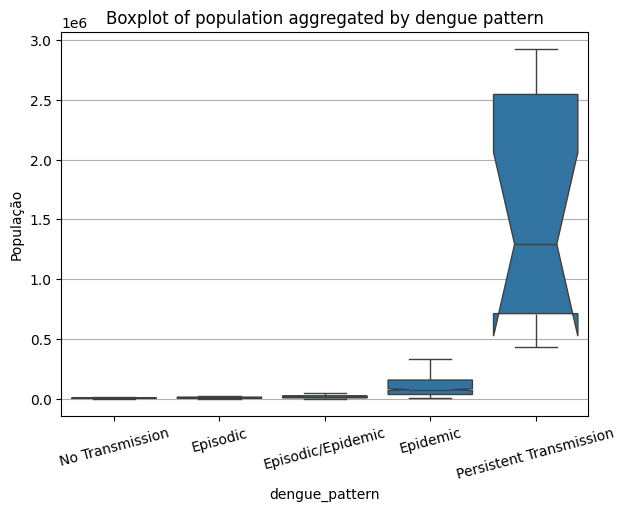

In [11]:
fig, ax = plt.subplots()

sns.boxplot(x='dengue_pattern', y='pop22', data=df_det, showfliers = False, order = prof_order, ax=ax,notch = True)

ax.set_ylabel('População')

ax.grid(True, axis='y')

ax.set_title('Boxplot of population aggregated by dengue pattern')

plt.tight_layout()
plt.xticks(rotation=15)  # Rotate x labels if needed

# Set the ticks for the x-axis (or y-axis if preferred)
#plt.yticks(custom_ticks)


#plt.savefig('../figures/boxplot_pop.png',  dpi = 300, bbox_inches = 'tight')
plt.show()

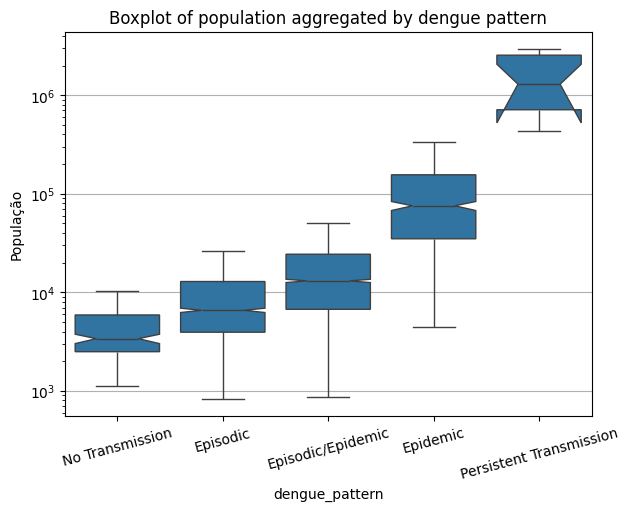

In [12]:
fig, ax = plt.subplots()

sns.boxplot(x='dengue_pattern', y='pop22', data=df_det, showfliers = False, order = prof_order, ax=ax,notch = True)

ax.set_ylabel('População')

ax.grid(True, axis='y')

ax.set_title('Boxplot of population aggregated by dengue pattern')

plt.tight_layout()
plt.xticks(rotation=15)  # Rotate x labels if needed

# Set the ticks for the x-axis (or y-axis if preferred)
#plt.yticks(custom_ticks)
plt.yscale('log')

#plt.savefig('../figures/boxplot_pop.png',  dpi = 300, bbox_inches = 'tight')
plt.show()

Boxplot da altitude: 

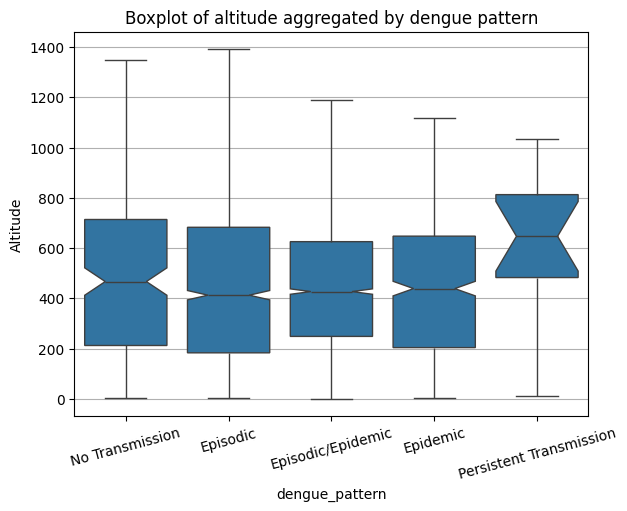

In [14]:
fig, ax = plt.subplots()

sns.boxplot(x='dengue_pattern', y='altitude', data=df_det, showfliers = False,  order = prof_order, ax=ax, notch = True)

ax.set_ylabel('Altitude')

ax.grid(True, axis='y')

ax.set_title('Boxplot of altitude aggregated by dengue pattern')

plt.tight_layout()
plt.xticks(rotation=15)  # Rotate x labels if needed

plt.savefig('../figures/boxplot_alt.png',  dpi = 300, bbox_inches = 'tight')
plt.show()

In [18]:
df_det.head()

,muni_code,muni_name,uf_code,uf_acr,tipo_regiao,bioma,altitude,koppen,pop22,prop_esgot,prop_abast,prop_residuo,dengue_pattern
0,1100015,Alta Floresta D'oeste,11,RO,não metropolitana,amazonia,246.08,Am,21558,"2,24","93,68","56,86",Episodic/Epidemic
1,1100023,Ariquemes,11,RO,não metropolitana,amazonia,165.90,Am,100896,"8,91","98,57","85,14",Epidemic
2,1100031,Cabixi,11,RO,não metropolitana,amazonia,224.18,Am,5107,"21,01","95,49","49,77",Episodic/Epidemic
3,1100049,Cacoal,11,RO,metropolitana,amazonia,229.95,Am,92202,"54,03","98,16","78,94",Epidemic
4,1100056,Cerejeiras,11,RO,não metropolitana,amazonia,192.22,Am,15237,"16,73","98,62","78,35",Episodic/Epidemic


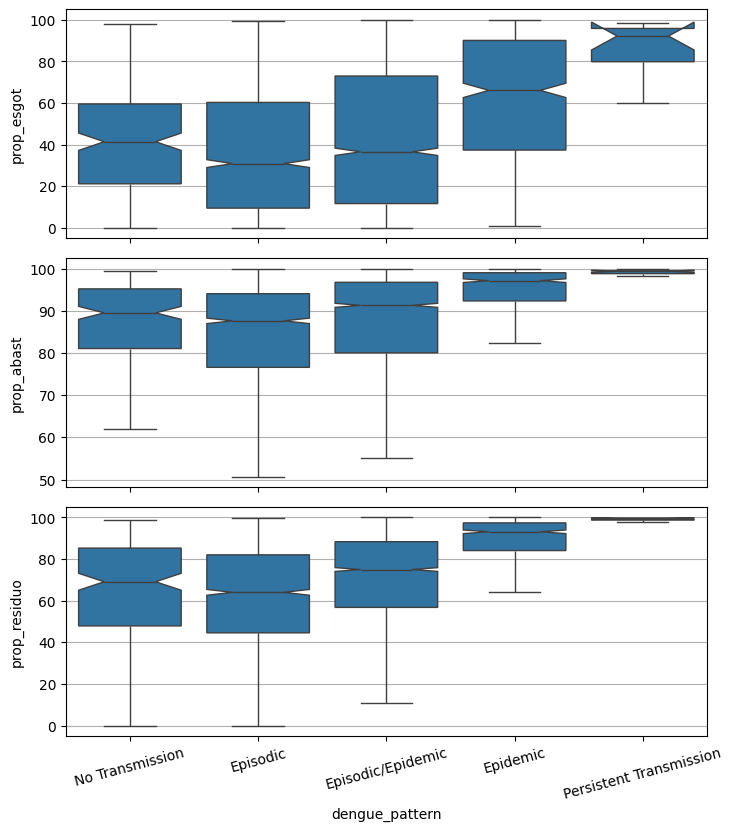

In [24]:
fig, ax = plt.subplots(3,1, figsize = (7.5,8), sharex = True)

sns.boxplot(x='dengue_pattern', y='prop_esgot', data=df_det, showfliers = False,  order = prof_order, ax=ax[0], notch = True)

#ax.set_ylabel('Altitude')

ax[0].grid(True, axis='y')

sns.boxplot(x='dengue_pattern', y='prop_abast', data=df_det, showfliers = False,  order = prof_order, ax=ax[1], notch = True)

ax[1].grid(True, axis='y')

sns.boxplot(x='dengue_pattern', y='prop_residuo', data=df_det, showfliers = False,  order = prof_order, ax=ax[2], notch = True)

ax[2].grid(True, axis='y')

#ax.set_title('Boxplot of altitude aggregated by dengue pattern')

plt.tight_layout()
plt.xticks(rotation=15)  # Rotate x labels if needed

plt.savefig('../figures/boxplot_ibge.png',  dpi = 300, bbox_inches = 'tight')
plt.show()